# 1.1. Приложение нагрузок и связей

### Beam.apply_load()

Метод `apply_load(value, start, order, end=None)` добавляет нагрузки на балку.

**Параметры:**

**value:** символическое значение

Значение приложенной нагрузки должно иметь единицы измерения [Сила/(Расстояние**(n+1))], где n — порядок приложенной нагрузки. Единицы измерения приложенной нагрузки:

+ Для моментов единица измерения = кН·м
+ Для точечных нагрузок единица измерения = кН
+ При постоянной распределенной нагрузке единица измерения = кН/м
+ Для нагрузок, изменяющихся по наклонной плоскости, единица измерения = кН/м/м
+ Для параболических нагрузок единица измерения = кН/м/м/м

**start:** символическое значение

Начальная точка приложенной нагрузки. Для точечных моментов и точечных сил это место приложения нагрузки.

**order:** порядок, целое число

Порядок приложенной нагрузки.

+ Для моментов порядок = -2
+ Для точечных нагрузок порядок = -1
+ При постоянной распределенной нагрузке порядок равен 0
+ Для наклонных нагрузок порядок = 1
+ Для параболических нагрузок порядок равен = 2

**end:** символическое значение, необязательно. Необязательный аргумент, который можно использовать, если конечная точка нагрузки находится в пределах длины балки.

#### Пример

Есть балка длиной 4 метра. В начале балки приложен момент величиной 3 Н·м по часовой стрелке. В верхней части балки на расстоянии 2 метра от начала приложена точечная нагрузка величиной 4 Н, а также параболическая треугольная нагрузка величиной 2 Н/м, действующая от 2 до 3 метров снизу балки.

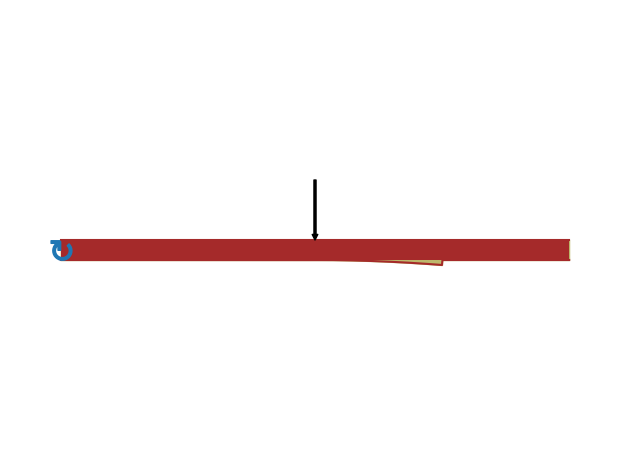

-3*SingularityFunction(x, 0, -2) + 4*SingularityFunction(x, 2, -1) - 2*SingularityFunction(x, 2, 2) + 2*SingularityFunction(x, 3, 0) + 4*SingularityFunction(x, 3, 1) + 2*SingularityFunction(x, 3, 2)

In [7]:
from sympy.physics.continuum_mechanics.beam import Beam
from sympy import symbols
E, I = symbols('E, I')
b = Beam(4, E, I)
b.apply_load(-3, 0, -2)
b.apply_load(4, 2, -1)
b.apply_load(-2, 2, 2, end=3)
p = b.draw()
p.show()
b.load

### Beam.apply_support()
`apply_support(loc, type='fixed')` Этот метод применяет опору к заданному объекту балки и возвращает обозначение неизвестной реакции (реакций).

**Параметры:**

**loc** : Sympifyable

> Координата точки, в которой прикладывается опора.

**type** : строка

> Определяет тип прикладываемой опоры балки. Для приложения опорной связи с: - нулевой степенью свободы, type = "fixed" (заделка) - одной степенью свободы, type = "pin" (шарнирно-неподвижная опора) - двумя степенями свободы, type = "roller" (шарнирно-подвижная опора)

**Возвращает:**

Обозначение (Symbol) или кортеж обозначений (Symbol)

> Неизвестная опорная реакция в виде обозначения. - Symbol(реакция_сила), если type = "pin" или "roller" - Symbol(реакция_сила), Symbol(реакция_момент), если type = "fixed"

#### Пример
Есть балка длиной 20 метров. В конце балки приложен момент величиной 100 Н·м по часовой стрелке. В верхней части балки на расстоянии 10 метров от начала приложена точечная нагрузка величиной 8 Н. В начале балки заделка, а в конце — шарнирно-подвижная опора.

Принимается правило знаков: направленные вверх силы и момент по часовой стрелке считаются положительными.

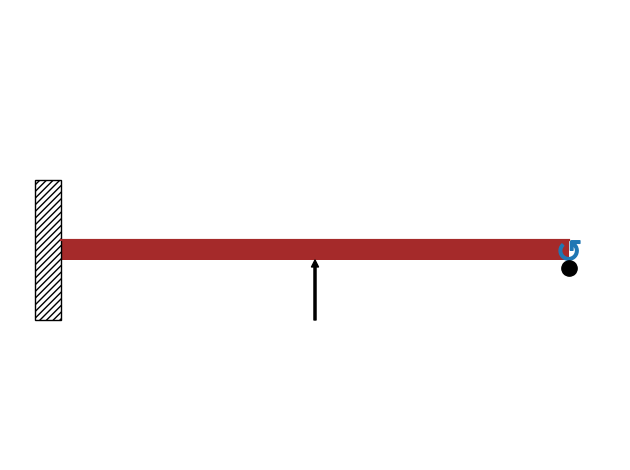

In [8]:
from sympy.physics.continuum_mechanics.beam import Beam
from sympy import symbols
E, I = symbols('E, I')
b = Beam(20, E, I)
p0, m0 = b.apply_support(0, 'fixed')
p1 = b.apply_support(20, 'roller')
b.apply_load(-8, 10, -1)
b.apply_load(100, 20, -2)
b.solve_for_reaction_loads(p0, m0, p1)
p = b.draw()
p.show()

In [9]:
b.reaction_loads

{R_0: -2, M_0: 20, R_20: 10}

In [10]:
b.reaction_loads[p0]

-2

In [11]:
b.load

20*SingularityFunction(x, 0, -2) - 2*SingularityFunction(x, 0, -1) - 8*SingularityFunction(x, 10, -1) + 100*SingularityFunction(x, 20, -2) + 10*SingularityFunction(x, 20, -1)

### Beam.apply_rotation_hinge()
`apply_rotation_hinge(loc)` Этот метод моделирует цилиндрический шарнир в отдельно взятой точке балки.

**Параметры:**

**loc** : Sympifyable. Место расположения шарнира.

Возвращает cкачок угла поворота, умноженный на модуль упругости и момент инерции, в символьном виде.

#### Пример

Рассматривается балка длиной 15 метров. Шарнирно-неподвижные опоры расположены на расстояниях 0 и 10 метров. На конце балки находится жесткая заделка. В конструкции имеются два шарнира, допускающих поворот: один на отметке 5 метров, другой — на отметке 10 метров. К шарниру на отметке 5 метров приложена сосредоточенная сила величиной 10 кН. На участке от 10 метров до конца балки действует распределенная нагрузка интенсивностью 5 кН/м.

Принято правило знаков: направленные вверх силы и момент, действующий по часовой стрелке, считаются положительными.

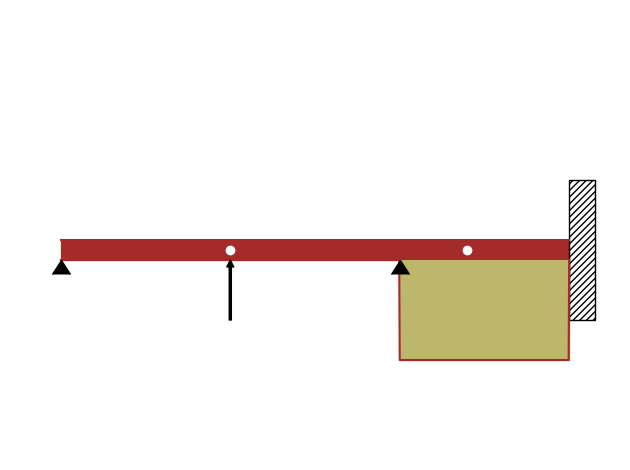

In [12]:
from sympy.physics.continuum_mechanics.beam import Beam
from sympy import symbols
E, I = symbols('E, I')
b = Beam(15, E, I)
r0 = b.apply_support(0, type='pin')
r10 = b.apply_support(10, type='pin')
r15, m15 = b.apply_support(15, type='fixed')
p5 = b.apply_rotation_hinge(5)
p12 = b.apply_rotation_hinge(12)
b.apply_load(-10, 5, -1)
b.apply_load(-5, 10, 0, 15)
b.solve_for_reaction_loads(r0, r10, r15, m15)
p = b.draw()
p.show()

In [13]:
b.reaction_loads

{R_0: 0, R_10: 40, R_15: -5, M_15: -75/2}

In [14]:
b.rotation_jumps

{P_5: 9625/(24*E*I), P_12: -1875/(16*E*I)}

In [15]:
b.bending_moment()

-9625*SingularityFunction(x, 5, -1)/24 + 10*SingularityFunction(x, 5, 1) - 40*SingularityFunction(x, 10, 1) + 5*SingularityFunction(x, 10, 2)/2 + 1875*SingularityFunction(x, 12, -1)/16 + 75*SingularityFunction(x, 15, 0)/2 + 5*SingularityFunction(x, 15, 1) - 5*SingularityFunction(x, 15, 2)/2

### Beam.apply_sliding_hinge()

`apply_sliding_hinge(loc)` Данный метод моделирует установку скользящего шарнира (ползуна) в заданной точке балки.

**Параметры:**

**loc** : Sympifyable

> Положение точки, в которой прикладывается шарнир (здесь: скользящая заделка).

**Возвращает:**

Symbol

> Неизвестный скачок прогиба, умноженный на модуль упругости и момент инерции, в виде символа.

#### Пример
Имеется балка длиной 13 метров. В начале расположена жесткая заделка. На конце находится шарнирно-неподвижная опора. Скользящая заделка (ползун) расположена на расстоянии 8 метров. Сосредоточенная сила величиной 10 кН приложена к шарниру на отметке 5 метров.

Используется правило знаков, согласно которому направленные вверх силы и момент, действующий по часовой стрелке, считаются положительными.

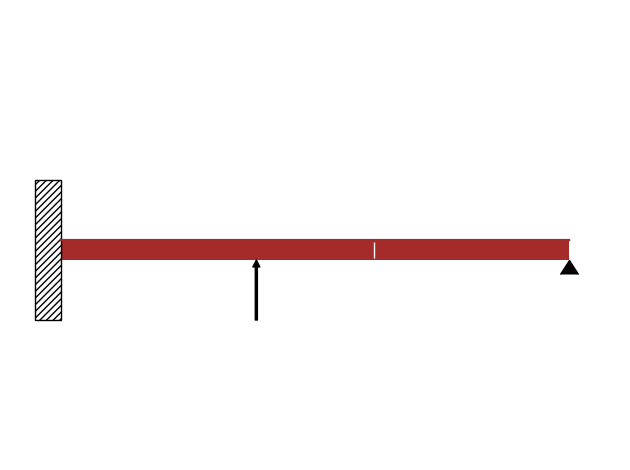

In [16]:
from sympy.physics.continuum_mechanics.beam import Beam
from sympy import symbols
from sympy.physics.continuum_mechanics.beam import Beam
b = Beam(13, 20, 20)
r0, m0 = b.apply_support(0, type="fixed")
s8 = b.apply_sliding_hinge(8)
r13 = b.apply_support(13, type="pin")
b.apply_load(-10, 5, -1)
b.solve_for_reaction_loads(r0, m0, r13)
p = b.draw()
p.show()

In [17]:
b.reaction_loads

{R_0: 10, M_0: -50, R_13: 0}

In [18]:
b.deflection_jumps

{W_8: 85/24}

In [19]:
b.deflection_jumps[s8]

85/24

In [20]:
b.bending_moment()

50*SingularityFunction(x, 0, 0) - 10*SingularityFunction(x, 0, 1) + 10*SingularityFunction(x, 5, 1) - 4250*SingularityFunction(x, 8, -2)/3

In [21]:
b.deflection()

-SingularityFunction(x, 0, 2)/16 + SingularityFunction(x, 0, 3)/240 - SingularityFunction(x, 5, 3)/240 + 85*SingularityFunction(x, 8, 0)/24

### Beam.remove_load()

`remove_load(value, start, order, end=None)`

Данный метод удаляет конкретную нагрузку на балке. Возвращает ValueError, если нагрузка, переданная в качестве аргумента, отсутствует на балке.

**Параметры**

**value**: Sympifyable

> Величина приложенной нагрузки.

**ptart**: Sympifyable

> Начальная точка приложения нагрузки. Для сосредоточенных моментов и сил это место приложения.

**order**: Integer

> Порядок приложенной нагрузки.
> - Для моментов: order= -2,
> - Для сосредоточенных сил: order=-1,
> - Для постоянной распределённой нагрузки: order=0,
> - Для линейно возрастающей нагрузки: order=1,
> - Для параболически возрастающей нагрузки: order=2,
> - … и так далее.

**end**: Sympifyable, необязательный

> Необязательный аргумент, который может использоваться, если нагрузка имеет конечную точку в пределах длины балки.

#### Пример

Имеется балка длиной 4 метра. Момент величиной 3 Н·м приложен по часовой стрелке в начале балки. Сосредоточенная сила величиной 4 Н приложена сверху балки на расстоянии 2 метра от начала, и параболически возрастающая нагрузка величиной 2 Н/м приложена снизу балки на участке от 2 до 3 метров от начала.

In [22]:
from sympy.physics.continuum_mechanics.beam import Beam
from sympy import symbols
E, I = symbols('E, I')
b = Beam(4, E, I)
b.apply_load(-3, 0, -2)
b.apply_load(4, 2, -1)
b.apply_load(-2, 2, 2, end=3)
b.load

-3*SingularityFunction(x, 0, -2) + 4*SingularityFunction(x, 2, -1) - 2*SingularityFunction(x, 2, 2) + 2*SingularityFunction(x, 3, 0) + 4*SingularityFunction(x, 3, 1) + 2*SingularityFunction(x, 3, 2)

In [23]:
b.remove_load(-2, 2, 2, end = 3)
b.load

-3*SingularityFunction(x, 0, -2) + 4*SingularityFunction(x, 2, -1)